In [4]:
import sys, os
sys.path.append(os.path.abspath(".."))

from src.dataset_rich import DownscaleDatasetRich
from src.model_cnn import UNetDownscale

In [10]:


ds = DownscaleDatasetRich(
    base_nc_path="../.data/downscaling_splits/train_norm.nc",
    extra_nc_path="../.data/downscaling_splits_extra/train_extra_norm.nc",
    topo_nc_path="../.data/ETOPO2/topography_feature_stats_norm.nc",
)

x, y, mask = ds[0]
print("x shape:", x.shape)
print("y shape:", y.shape)
print("mask shape:", mask.shape)

x shape: torch.Size([7, 240, 311])
y shape: torch.Size([1, 240, 311])
mask shape: torch.Size([1, 240, 311])


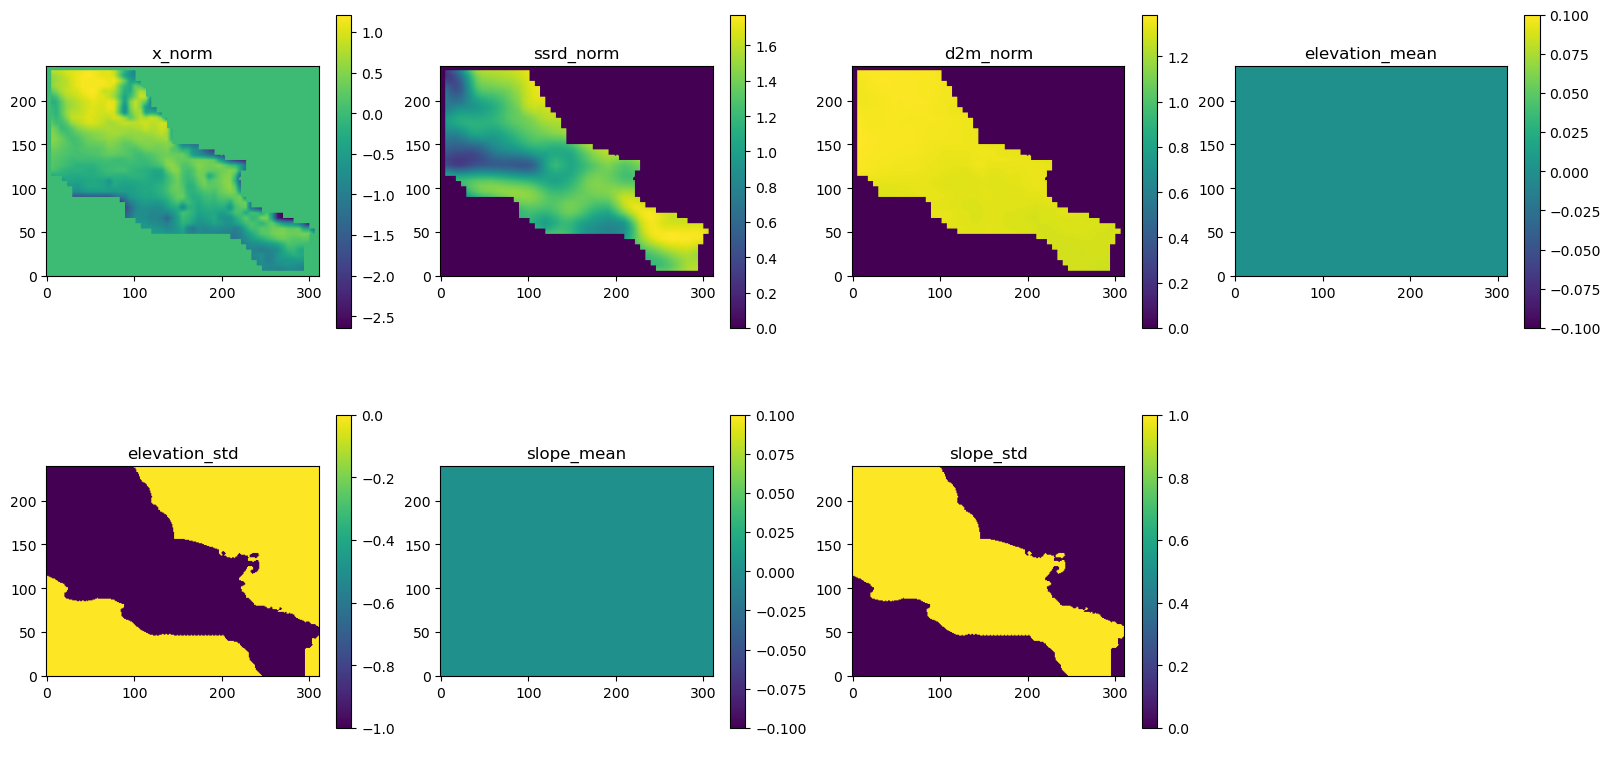

In [11]:
import matplotlib.pyplot as plt

channel_names = [
    "x_norm",
    "ssrd_norm",
    "d2m_norm",
    "elevation_mean",
    "elevation_std",
    "slope_mean",
    "slope_std",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)

for i, ax in enumerate(axes.flat[:7]):
    im = ax.imshow(x[i].numpy(), origin="lower")
    ax.set_title(channel_names[i])
    plt.colorbar(im, ax=ax, shrink=0.8)

axes.flat[-1].axis("off")
plt.show()

In [12]:


model = UNetDownscale(in_channels=7)
x_batch = x.unsqueeze(0)   # add batch dim
y_pred = model(x_batch)

print("input shape :", x_batch.shape)
print("output shape:", y_pred.shape)

input shape : torch.Size([1, 7, 240, 311])
output shape: torch.Size([1, 1, 240, 311])


In [13]:
from torch.utils.data import DataLoader

loader = DataLoader(ds, batch_size=4, shuffle=True, num_workers=0)
xb, yb, mb = next(iter(loader))

print("xb:", xb.shape)
print("yb:", yb.shape)
print("mb:", mb.shape)

xb: torch.Size([4, 7, 240, 311])
yb: torch.Size([4, 1, 240, 311])
mb: torch.Size([4, 1, 240, 311])
